In [12]:
# --- Core libraries ---
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import Point

# --- Scikit-learn: model training, preprocessing, CV, evaluation ---
from sklearn.model_selection import (
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
    GridSearchCV
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    balanced_accuracy_score,
    roc_auc_score,
    make_scorer,
    ConfusionMatrixDisplay
)
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import BallTree

# --- XGBoost ---
from xgboost import XGBRegressor, plot_tree, plot_importance
import xgboost  # Optional: useful for checking version

# --- Other ---
from haversine import haversine
import scipy.stats as stats
import gstools as gs #variogram modeling
from sklearn.metrics import pairwise_distances # for distance calculations


In [ ]:
print("Current working directory:", os.getcwd())

#load in 
df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/RFgdpadded12-7.csv")  # for variogram, etc.
df = df_raw.copy()  # working copy for feature engineering + model prep
print(list(df.columns))



Current working directory: /home/sebastian-dohne/Documents/FinalProject/code/analysis/kagglefeatureengineering/xgboost
['id', 'Data.ID', 'Location', 'State.Region.County.Province', 'Country', 'Continent', 'Latitude..N.S.', 'Longitude..E.W.', 'Conversion.for.latitude', 'Conversion.for.longitude', 'Location.source', 'Observation.period', 'Wheat.Type', 'Crop.variety', 'Tillage.type', 'Planting.date', 'Treatment', 'Treatment.type', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Irrigation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.type', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Emissions..yes.no.', 'Pest.prescence....64', 'Pest.detected...65', 'Pest.severity.score.......66', 'rainfed_start_date', 'rainfed_end_date', 'irr_start_date', 'irr_end_date', 'start_date', 'end_date', 'Planting.date.1', 'Harvesting.date.1', 'Soil_N', 'pr_irrigated', 

/tmp/ipykernel_139656/1271602068.py:3: DtypeWarning: Columns (6,7,13,14,15,16,17,20,22,23,29,31,33,34,35,36,37,44,45,69,70,74,75,76) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("../../../../data/finaldatasets/testdata/RFgdpadded12-7.csv")  # for variogram, etc.


In [4]:
# data summary table
def summarize_column(col_data):
    numeric_data = pd.to_numeric(col_data, errors='coerce')
    is_numeric = numeric_data.notna().sum() > 0
    return {
        "dtype": col_data.dtype,
        "count": col_data.notna().sum(),
        "pct_complete": round(col_data.notna().mean() * 100, 1),
        "n_unique": col_data.nunique(dropna=True)
    }

# Build summary
summary_long = (
    pd.DataFrame([
        {"variable": col, **summarize_column(df[col])}
        for col in df.columns
    ])
    .sort_values(by="pct_complete", ascending=False)
    .reset_index(drop=True)
)

# Print in markdown table format
from tabulate import tabulate
print(tabulate(
    summary_long,
    headers="keys",
    tablefmt="github",
    showindex=False
))

| variable                                              | dtype   |   count |   pct_complete |   n_unique |
|-------------------------------------------------------|---------|---------|----------------|------------|
| id                                                    | int64   |   78013 |          100   |      77619 |
| Location.source                                       | object  |   78013 |          100   |          9 |
| year                                                  | int64   |   78013 |          100   |         42 |
| Elevation                                             | float64 |   78013 |          100   |        202 |
| Data.ID                                               | object  |   78013 |          100   |         54 |
| end_date                                              | int64   |   78013 |          100   |         10 |
| start_date                                            | int64   |   78013 |          100   |          7 |
| Grain.yield..tons.ha.1.   

In [5]:
# Define groups of columns to drop
LOCATION_COLS = [
    "id", "Data.ID", "Location", "State.Region.County.Province", "Country", "Continent",
    "Latitude..N.S.", "Longitude..E.W.",
    "Location.source", "Observation.period", "X", "Y", "unit_code"
]

# "Conversion.for.latitude", "Conversion.for.longitude"
HIGH_CARDINALITY_COLS = [
    "Treatment.type", "Emissions..yes.no.",
    "Irrigation..mm.", "Harvesting.date.1","Pest.severity.score.......66",
    "Agricultural_Use_–_Other_Pesticides_nes_(t)","Agricultural_Use_–_Rodenticides_(t)", 
    "irr_end_date", "end_date", "rainfed_end_date"
]


COLLINEAR_COLS = [
    "harvest_month", "harvest_date_clean", "harvest_week",
    "Planting.date", "Planting_Month", "Planting.date.1", "Planting_Week"
]

# These columns are used for testing purposes
TESTCOLUMNS = ["Wheat.Type", "N.type"]

# Combine all columns to drop into a single set (to avoid duplicates)
COLUMNS_TO_DROP = set(LOCATION_COLS + HIGH_CARDINALITY_COLS + COLLINEAR_COLS + TESTCOLUMNS)

# Drop all listed columns if they exist in the DataFrame
df_cleaned = df.drop(columns=[col for col in COLUMNS_TO_DROP if col in df.columns])

# Optional: Review dropped and remaining columns
print("Original shape:", df.shape)
print("Shape after dropping:", df_cleaned.shape)
print("Dropped columns:", [col for col in COLUMNS_TO_DROP if col in df.columns])
print("Remaining columns:", df_cleaned.columns.tolist())

# Drop columns with less than 20% completeness
df_cleaned = df_cleaned.loc[:, df_cleaned.count() / len(df_cleaned) >= 0.2]

# Drop unnamed columns and rows with NaN in the target variable
df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.str.contains('^Unnamed')]
df_cleaned = df_cleaned.dropna(subset=["Grain.yield..tons.ha.1."])


Original shape: (78013, 95)
Shape after dropping: (78013, 68)
Dropped columns: ['Longitude..E.W.', 'Country', 'Observation.period', 'end_date', 'Planting.date.1', 'Location.source', 'Continent', 'Emissions..yes.no.', 'Latitude..N.S.', 'id', 'harvest_date_clean', 'Irrigation..mm.', 'rainfed_end_date', 'Planting.date', 'Data.ID', 'harvest_week', 'Planting_Month', 'State.Region.County.Province', 'Pest.severity.score.......66', 'harvest_month', 'Location', 'Treatment.type', 'Harvesting.date.1', 'Planting_Week', 'N.type', 'Wheat.Type', 'irr_end_date']
Remaining columns: ['Conversion.for.latitude', 'Conversion.for.longitude', 'Crop.variety', 'Tillage.type', 'Treatment', 'Grain.yield..tons.ha.1.', 'Mean.annual.temperature..Â.C.', 'Water.regime', 'Mean.annual.precipitation..mm.', 'Soil.type', 'Sand', 'Silt', 'Clay', 'Soil.organic.carbon..g.C.kg.1.', 'Soil.pH', 'N.rate..kg.N.ha.1.', 'P.type', 'P.rate..kg.P.ha.1.', 'Plastic.film.mulching', 'Pest.prescence....64', 'Pest.detected...65', 'rainfed_s

In [6]:
#see how many labels there are before doing rf: 
df_cleaned.select_dtypes(include="object").nunique().sort_values(ascending=False)


Crop.variety            1304
Soil.type                 50
Tillage.type              22
Treatment_Category        14
irrigation_applied         4
Treatment                  2
Pest.prescence....64       2
dtype: int64

Spacial temporal semivariogram

In [18]:

# --- Parameters ---
n_sample = 10000
n_bins = 30

# --- 1. Select relevant columns & drop missing ---
df_variogram = df_raw[[
    "Conversion.for.longitude",
    "Conversion.for.latitude",
    "year",
    "Grain.yield..tons.ha.1."
]].dropna()

# --- 2. Subsample for speed & reset index ---
df_sampled = df_variogram.sample(n=n_sample, random_state=42).reset_index(drop=True)

# --- 3. Extract coordinates (X, Y, T) and values ---
coords = df_sampled[[
    "Conversion.for.longitude",
    "Conversion.for.latitude",
    "year"
]].values

values = df_sampled["Grain.yield..tons.ha.1."].values.reshape(-1, 1)  # shape (n, 1)

# --- 4. Compute pairwise distances in parallel ---
start = time.time()
dists = pairwise_distances(coords, n_jobs=-1)
elapsed = time.time() - start
print(f"Pairwise distances computed in {elapsed:.2f} seconds")

# --- 5. Flatten upper triangle and define distance bins ---
i_upper = np.triu_indices_from(dists, k=1)
dists_flat = dists[i_upper]
max_dist = np.percentile(dists_flat, 99)  # avoid outliers
bin_edges = np.linspace(0, max_dist, n_bins + 1)

# --- 6. Compute empirical spatiotemporal variogram ---
bin_centers, gamma = gs.vario_estimate(
    coords,
    values,
    bin_edges=bin_edges,
    mesh_type="unstructured"
)

# --- 7. Plot ---
plt.figure(figsize=(8, 5))
plt.plot(bin_centers, gamma, marker='o')
plt.xlabel("Spatiotemporal Distance (scaled units)")
plt.ylabel("Semivariance")
plt.title("Empirical Spatiotemporal Variogram (3D: Lon, Lat, Year)")
plt.grid(True)
plt.tight_layout()
plt.show()



Pairwise distances computed in 1.03 seconds


ValueError: Formatting: position tuple doesn't match dimension.

### Onehot encode and prepare data

In [52]:
# Start fresh
X = df_cleaned.copy()
y = X.pop("Grain.yield..tons.ha.1.")

# Add spatial coordinates
X["lon"] = df_cleaned["Conversion.for.longitude"]
X["lat"] = df_cleaned["Conversion.for.latitude"]

# Identify categorical columns
object_cols = X.select_dtypes(include="object").columns.tolist()

# One-hot encode all categorical features (no LabelEncoder needed)
X_encoded = pd.get_dummies(X, columns=object_cols, drop_first=False)

# Ensure all features are numeric (XGBoost-friendly)
X_encoded = X_encoded.astype(float)

# Optional: make all columns visible in output
pd.set_option('display.max_columns', None)

X_encoded.head()

,Conversion.for.latitude,Conversion.for.longitude,Mean.annual.precipitation..mm.,Sand,Silt,Clay,Soil.organic.carbon..g.C.kg.1.,Soil.pH,N.rate..kg.N.ha.1.,P.rate..kg.P.ha.1.,rainfed_start_date,irr_start_date,start_date,Soil_N,pr_irrigated,AEZ,Elevation,temp1,temp2,temp3,temp4,temp5,temp6,temp7,temp8,temp9,prc1,prc2,prc3,prc4,prc5,prc6,prc7,prc8,prc9,Irrigation.mm_clean,harvest_dayofyear,gdp,hdi,year,dryspells(5days),drydays(annualsum),Year_x,Agricultural_Use_–_Fungicides_and_Bactericides_(t),Agricultural_Use_–_Herbicides_(t),Agricultural_Use_–_Insecticides_(t),Agricultural_Use_–_Pesticides_(total)_(t),Use_per_area_of_cropland_–_Pesticides_(total)_(kg/ha),lon,lat,Crop.variety_03W10068,Crop.variety_05W90192,Crop.variety_05W90314,Crop.variety_05W90818,Crop.variety_06SB100-B,Crop.variety_08SB0008-B,Crop.variety_08SB0073,Crop.variety_08SB0658-B,Crop.variety_08SB0738,Crop.variety_08SB100,Crop.variety_116 CD,Crop.variety_18CP010011,Crop.variety_18CP010302,Crop.variety_18CP010312,Crop.variety_18PE500000,Crop.variety_18PE500002,Crop.variety_38IBWSN-97/DESTIN,Crop.variety_587-0149,Crop.variety_9852.1//ERYT1554.90/PEHLIVAN,Crop.variety_A.C. Barrie,Crop.variety_ACCORD7.2,Crop.variety_ADAGIO,Crop.variety_AF03-1,Crop.variety_AFINA,Crop.variety_AGRI/NAC//ATTILA/4/ERIT58-87//KS82W409/SPN/3/KRC66/SERI,Crop.variety_AGRI/NAC//ATTILA/6/TAST/SPRW//ZAR/5/YUANDONG 3/4/PPB8-68/CHRC/3/PYN//TAM101/AMIGO/7/494J6.11//TRAP#1/BOW,Crop.variety_AGRI/NAC//KAUZ/3/1D13.1/MLT/4/ATAY/GALVEZ87//SHARK-1,Crop.variety_AGRI/NAC//KAUZ/3/1D13.1/MLT/4/TX71A1039.V1*3/AMI//BUC/CHRC/5/BONITO-37,Crop.variety_ALMALY//PBW343/PASTOR,Crop.variety_ALMALY//PRL/2*PASTOR,Crop.variety_ALMALY/OBRYI,Crop.variety_ALPU01/3/FDL4/KAUZ//LAGOS-7/4/MAHON DEMIAS/3/HIM/CNDR//CA8055,Crop.variety_ALTAR 84/AE.SQ.(J BANGOR)//ESDA/3/KAUZ/STAR//U1254-1-5-1-1/TX89V4213 (OCW00S063S-2)/4/OK95548/TXHBG0358 (OK05303),Crop.variety_AM Eastwood,Crop.variety_ANZA,Crop.variety_AP VENOM,Crop.variety_APB 410089,Crop.variety_APB 510879,Crop.variety_APB-W04-7,Crop.variety_APB11512,Crop.variety_APB12104,Crop.variety_APB20-1,Crop.variety_APB33-A,Crop.variety_APB410117,Crop.variety_APB430429,Crop.variety_APB430701,Crop.variety_APB500553,Crop.variety_APB500709,Crop.variety_APB501089,Crop.variety_APB501129,Crop.variety_APB501189,Crop.variety_APB510453,Crop.variety_APB510477,Crop.variety_APB510478,Crop.variety_APB510479,Crop.variety_APB510480,Crop.variety_APB510482,Crop.variety_APB510483,Crop.variety_APB511829,Crop.variety_APB511830,Crop.variety_APB511831,Crop.variety_APB511832,Crop.variety_APB511834,Crop.variety_APB511835,Crop.variety_APB717,Crop.variety_APB770229,Crop.variety_APB8155,Crop.variety_APB8238,Crop.variety_APB89-1-13,Crop.variety_APB89-1-15B,Crop.variety_APB89-13\JHJIJ,Crop.variety_APB89-1B3R,Crop.variety_APBH-2B,Crop.variety_APBH-8,Crop.variety_APBH8-2,Crop.variety_APBHH8R,Crop.variety_APBMC-1,Crop.variety_APBNM-1,Crop.variety_APBW01-106-2B4,Crop.variety_APBW01-374-4,Crop.variety_APBW02AZ-228MT,Crop.variety_APBW02AZ-361,Crop.variety_APBW02AZ-365,Crop.variety_APBW02GE-19-1,Crop.variety_APBW02GE-19-6,Crop.variety_APBW03AZ-146,Crop.variety_APBW04-48,Crop.variety_APBW05AZ-137,Crop.variety_APBW05AZ-149,Crop.variety_APBW05AZ-176,Crop.variety_APBW1-10,Crop.variety_APBW10-8,Crop.variety_APBW11-6,Crop.variety_APBW8-2,Crop.variety_APBW9-3AL,Crop.variety_APBW93-11,Crop.variety_APBW94B-192,Crop.variety_APBW95-261,Crop.variety_APBW96-646,Crop.variety_APBW97-268,Crop.variety_APBW97-275,Crop.variety_APBW98-231,Crop.variety_APBW98-232,Crop.variety_APBW98-261,Crop.variety_APBW98-275,Crop.variety_APBW99OD-773,Crop.variety_APBW99OD-877,Crop.variety_APBW99OD-890,Crop.variety_ARS97135-9/O3A-B4//KS06O3A~49,Crop.variety_ART,Crop.variety_ART/KS990494-11-~O//KS06O3A~36,Crop.variety_ARZ,Crop.variety_ASSL TAM 204,Crop.variety_ASSL-TAM204,Crop.variety_ASSLTAM204,Crop.variety_ATIR,Crop.variety_ATOMO,Crop.variety_ATREVIDO,Crop.variety_AXE/TOSUNBEY,Crop.variety_AZAR2/78ZHONG291-64,Crop.variety_Abid,Crop.variety_Ada,Crop.variety_AiII198,C

RF with spacial and temporal blocking? 

In [53]:
#🌍 BLOCK 2: Spatial Grouping (Haversine Clustering)

coords = df_cleaned[['Conversion.for.latitude', 'Conversion.for.longitude']].dropna().values
coords_rad = np.deg2rad(coords)
tree = BallTree(coords_rad, metric='haversine')

radius_km = 100
radius = radius_km / 6371.0

groups, visited = [], np.zeros(len(coords), dtype=bool)
for i in range(len(coords)):
    if not visited[i]:
        inds = tree.query_radius([coords_rad[i]], r=radius)[0]
        groups.append(inds)
        visited[inds] = True

spatial_group_labels = np.zeros(len(coords), dtype=int)
for group_id, inds in enumerate(groups):
    spatial_group_labels[inds] = group_id

df_cleaned.loc[
    df_cleaned[['Conversion.for.latitude', 'Conversion.for.longitude']].dropna().index,
    'spatial_group'
] = spatial_group_labels


In [54]:
#⏳ BLOCK 3–4: Temporal & Combined Group Labels
temporal_groups = df_cleaned['year'].astype(str).values

combined_groups = np.array([
    f"S{int(spatial)}_T{temporal}" 
    for spatial, temporal in zip(df_cleaned['spatial_group'], temporal_groups)
])


In [55]:
# 🌲 BLOCK 5: XGBoost Regressor + Random Search + GroupKFold
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv = GroupKFold(n_splits=5)

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",        # efficient & sparsity-aware
    missing=np.nan,            # critical for NaN handling
    n_jobs=os.cpu_count() - 1,
    random_state=0
)

param_dist = {
    "n_estimators": [100, 250, 500],
    "max_depth": [4, 6, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0, 0.1, 1],
    "reg_lambda": [1, 5, 10]
}

search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    cv=cv.split(X_encoded, y, groups=combined_groups),
    verbose=1,
    n_jobs=-1
)

search.fit(X_encoded, y)
best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/home/sebastian-dohne/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

Final model running

✅ Final model trained in 0.06 minutes.
📈 Final Model Evaluation (on training data):
  MAE : 0.8682
  RMSE: 1.2408
  R²  : 0.7991


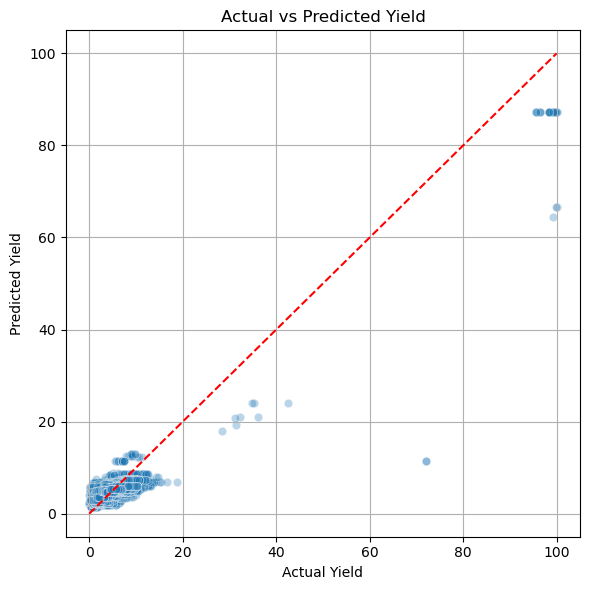

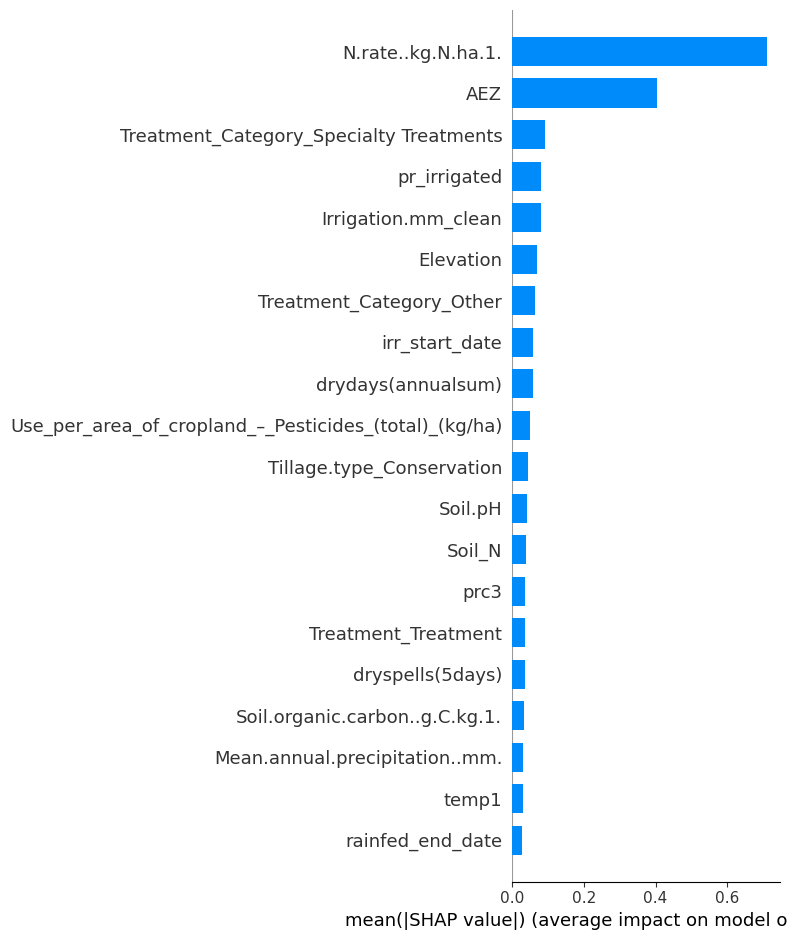

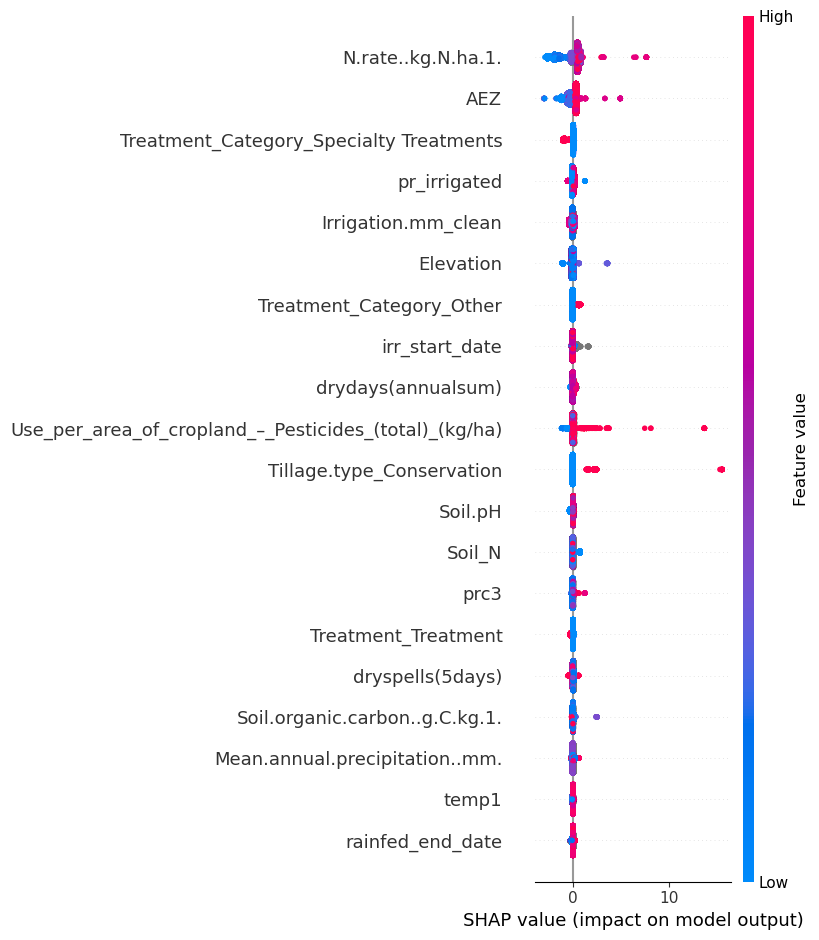

In [ ]:
# Get best hyperparameters from the random search
best_params = search.best_params_

# Build final model using those params
best_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    tree_method="hist",        # efficient & sparsity-aware
    missing=np.nan,
    n_jobs=os.cpu_count() - 1,
    random_state=0
)

# Train on full dataset
start_time = time.time()
best_model.fit(X_encoded, y)
print(f"✅ Final model trained in {(time.time() - start_time)/60:.2f} minutes.")

# Predict on full training set
y_pred = best_model.predict(X_encoded)

# 📊 Evaluation metrics
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"📈 Final Model Evaluation (on training data):")
print(f"  MAE : {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²  : {r2:.4f}")

# Actual vs Predicted Plot
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y, y=y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--', color='red')
plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Actual vs Predicted Yield")
plt.grid(True)
plt.tight_layout()
plt.show()

# SHAP Explanation (you can sample X_encoded for speed if needed)
explainer = shap.Explainer(best_model)
shap_values = explainer(X_encoded)

# Summary bar plot
shap.summary_plot(shap_values, X_encoded, plot_type="bar")

# Beeswarm plot
shap.summary_plot(shap_values, X_encoded)


Generate a variogram post model to see if spacioautocorrelation remains